## Wstępna analiza datasetu 

In [49]:
from pathlib import Path
import pandas as pd
import yaml
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

CONFIG_PATH = Path("F:/ZPB/eyepacs-dr-classification/configs/config.yaml")

with open(CONFIG_PATH, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

images_dir = Path(config["paths"]["images_dir"])
labels_csv = Path(config["paths"]["labels_csv"])

print("images_dir exists:", images_dir.exists())
print("labels_csv exists:", labels_csv.exists())


images_dir exists: True
labels_csv exists: True


In [46]:
labels_df = pd.read_csv(labels_csv)

print("Liczba wierszy i kolumn:", labels_df.shape)
print("Kolumny:", labels_df.columns.tolist())

class_counts = labels_df['level'].value_counts().sort_index()

class_percentages = (class_counts / len(labels_df) * 100).round(2)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages
})

display(class_distribution)

labels_df["binary_label"] = (labels_df["level"] > 0).astype(int)

binary_counts = labels_df["binary_label"].value_counts().sort_index()
binary_percentages = (binary_counts / len(labels_df) * 100).round(2)

binary_distribution = pd.DataFrame({
    "count": binary_counts,
    "percentage": binary_percentages
})

print("Rozkład klas dla wariantu binarnego:")
display(binary_distribution)

labels_df["side"] = labels_df["image"].str.extract(r"_(left|right)$")
labels_df["patient_id"] = labels_df["image"].str.replace(r"_(left|right)$", "", regex=True)

side_counts = labels_df["side"].value_counts().sort_index()

patient_sides = labels_df.pivot_table(
    index="patient_id",
    columns="side",
    values="image",
    aggfunc="count",
    fill_value=0
)

complete_pairs = ((patient_sides["left"] > 0) & (patient_sides["right"] > 0)).sum()
incomplete_pairs = len(patient_sides) - complete_pairs

summary_pairs = pd.DataFrame({
    "value": [
        len(labels_df),
        len(patient_sides),
        complete_pairs,
        incomplete_pairs
    ]
}, index=[
    "liczba zdjęć",
    "liczba pacjentów / ID",
    "liczba kompletów left+right",
    "liczba niepełnych kompletów"
])

display(summary_pairs)

labels_df["image_path"] = labels_df["image"].apply(lambda name: images_dir / f"{name}.jpeg")
labels_df["file_exists"] = labels_df["image_path"].apply(lambda path: path.exists())

existing_files = labels_df["file_exists"].sum()
missing_files = (~labels_df["file_exists"]).sum()

print("kompletne:", existing_files)
print("brakujące pliki:", missing_files)

if missing_files > 0:
    display(labels_df.loc[~labels_df["file_exists"], ["image", "image_path"]].head(10))

Liczba wierszy i kolumn: (35126, 2)
Kolumny: ['image', 'level']


,count,percentage
level,,
0,25810,73.48
1,2443,6.95
2,5292,15.07
3,873,2.49
4,708,2.02


Rozkład klas dla wariantu binarnego:


,count,percentage
binary_label,,
0,25810,73.48
1,9316,26.52


,value
liczba zdjęć,35126
liczba pacjentów / ID,17563
liczba kompletów left+right,17563
liczba niepełnych kompletów,0


Exception ignored in: <function tqdm.__del__ at 0x000001C5D941BBA0>
Traceback (most recent call last):
  File "f:\ZPB\eyepacs-dr-classification\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "f:\ZPB\eyepacs-dr-classification\.venv\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


kompletne: 35126
brakujące pliki: 0


10_left.jpeg (4752, 3168) RGB class: 0
10_right.jpeg (4752, 3168) RGB class: 0
13_left.jpeg (2592, 1944) RGB class: 0
13_right.jpeg (2592, 1944) RGB class: 0
15_left.jpeg (4928, 3264) RGB class: 1
15_right.jpeg (4928, 3264) RGB class: 2


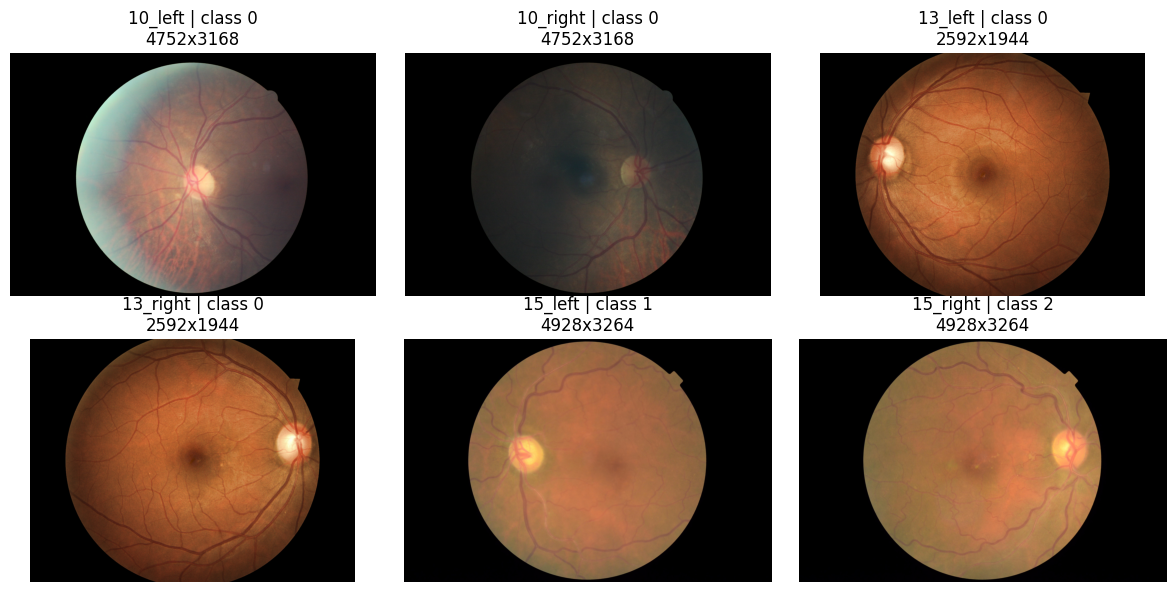

In [34]:
sample_df = labels_df.head(6)

plt.figure(figsize=(12, 6))

for i, row in enumerate(sample_df.itertuples(), start=1):
    with Image.open(row.image_path) as img:
        print(row.image_path.name, img.size, img.mode, "class:", row.level)

        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(f"{row.image} | class {row.level}\n{img.size[0]}x{img.size[1]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
image_metadata = []

for row in labels_df.itertuples():
    with Image.open(row.image_path) as img:
        width, height = img.size

        image_metadata.append({
            "image": row.image,
            "level": row.level,
            "side": row.side,
            "patient_id": row.patient_id,
            "width": width,
            "height": height,
            "mode": img.mode,
            "aspect_ratio": round(width / height, 4)
        })

metadata_df = pd.DataFrame(image_metadata)

resolution_counts = (
    metadata_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
    .reset_index(drop=True)
)

print("Liczba sprawdzonych obrazów:", len(metadata_df))
print("Liczba unikalnych rozdzielczości:", len(resolution_counts))

print("\nTryby obrazów:")
display(metadata_df["mode"].value_counts().reset_index(name="count"))

print("\nPodstawowe statystyki rozdzielczości:")
display(metadata_df[["width", "height", "aspect_ratio"]].describe())

print("\nWszystkie rozdzielczości i liczba przypadków:")
display(resolution_counts)

Liczba sprawdzonych obrazów: 35126
Liczba unikalnych rozdzielczości: 29

Tryby obrazów:


,mode,count
0,RGB,35126



Podstawowe statystyki rozdzielczości:


,width,height,aspect_ratio
count,35126.000000,35126.000000,35126.000000
mean,3636.655241,2473.033166,1.462005
std,801.830170,471.474465,0.073767
min,400.000000,289.000000,1.000000
25%,2816.000000,1944.000000,1.500000
50%,3888.000000,2592.000000,1.500000
75%,3888.000000,2592.000000,1.500000
max,5184.000000,3456.000000,1.513500



Wszystkie rozdzielczości i liczba przypadków:


,width,height,count
0,3888,2592,10352
1,4752,3168,5550
2,3504,2336,4144
3,2560,1920,3858
4,2592,1944,3795
5,3456,2304,1628
6,4928,3264,1558
7,4272,2848,854
8,3008,2000,836
9,2816,1880,508


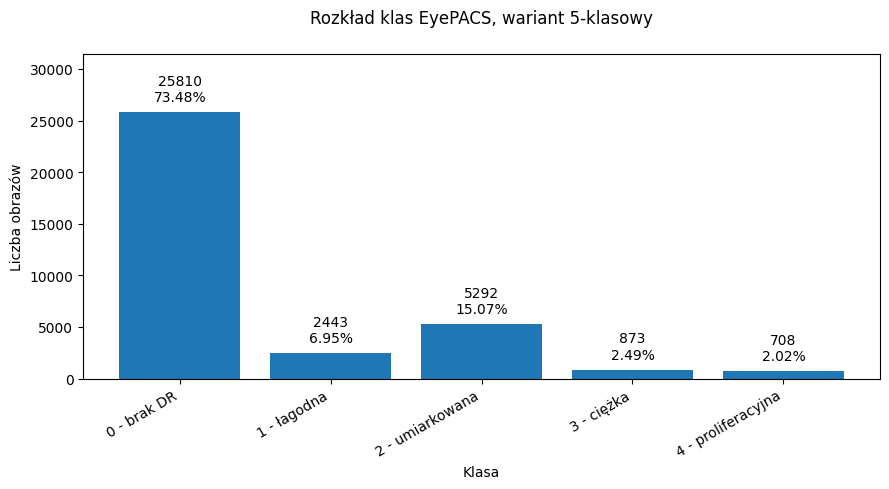

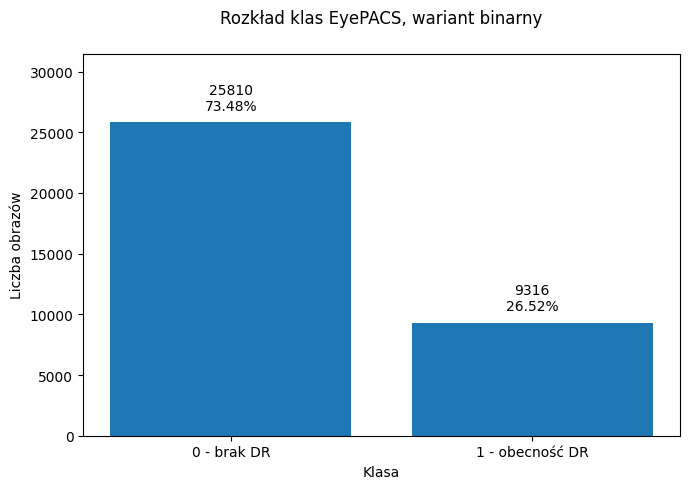

In [48]:
plt.figure(figsize=(9, 5))
plt.bar(class_distribution.index, class_distribution["count"])

plt.title("Rozkład klas EyePACS, wariant 5-klasowy", pad=22)
plt.xlabel("Klasa")
plt.ylabel("Liczba obrazów")
plt.xticks(rotation=30, ha="right")

max_count = class_distribution["count"].max()
plt.ylim(0, max_count * 1.22)

for i, value in enumerate(class_distribution["count"]):
    percentage = class_distribution["percentage"].iloc[i]
    plt.text(
        i,
        value + max_count * 0.03,
        f"{value}\n{percentage}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.bar(binary_distribution.index, binary_distribution["count"])

plt.title("Rozkład klas EyePACS, wariant binarny", pad=22)
plt.xlabel("Klasa")
plt.ylabel("Liczba obrazów")

max_count = binary_distribution["count"].max()
plt.ylim(0, max_count * 1.22)

for i, value in enumerate(binary_distribution["count"]):
    percentage = binary_distribution["percentage"].iloc[i]
    plt.text(
        i,
        value + max_count * 0.03,
        f"{value}\n{percentage}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [53]:
seed = config.get("project", {}).get("random_seed", 42)

if "binary_label" not in labels_df.columns:
    labels_df["binary_label"] = (labels_df["level"] > 0).astype(int)

if "patient_id" not in labels_df.columns:
    labels_df["patient_id"] = labels_df["image"].str.replace(r"_(left|right)$", "", regex=True)

patient_df = (
    labels_df
    .groupby("patient_id")
    .agg(
        max_level=("level", "max"),
        has_dr=("binary_label", "max"),
        image_count=("image", "count")
    )
    .reset_index()
)

train_patients, temp_patients = train_test_split(
    patient_df,
    test_size=0.30,
    random_state=seed,
    stratify=patient_df["max_level"]
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=seed,
    stratify=temp_patients["max_level"]
)

labels_df["split"] = "none"

labels_df.loc[labels_df["patient_id"].isin(train_patients["patient_id"]), "split"] = "train"
labels_df.loc[labels_df["patient_id"].isin(val_patients["patient_id"]), "split"] = "val"
labels_df.loc[labels_df["patient_id"].isin(test_patients["patient_id"]), "split"] = "test"

print("Liczba obrazów w splitach:")
display(labels_df["split"].value_counts())

print("Rozkład klas 0-4 w splitach:")
display(pd.crosstab(labels_df["split"], labels_df["level"], margins=True))

print("Rozkład binarny w splitach:")
display(pd.crosstab(labels_df["split"], labels_df["binary_label"], margins=True))

train_ids = set(train_patients["patient_id"])
val_ids = set(val_patients["patient_id"])
test_ids = set(test_patients["patient_id"])

print("Przeciek train-val:", len(train_ids & val_ids))
print("Przeciek train-test:", len(train_ids & test_ids))
print("Przeciek val-test:", len(val_ids & test_ids))





Liczba obrazów w splitach:


split
train    24588
test      5270
val       5268
Name: count, dtype: int64

Rozkład klas 0-4 w splitach:


level,0,1,2,3,4,All
split,,,,,,
test,3875,368,790,129,108,5270
train,18070,1708,3704,611,495,24588
val,3865,367,798,133,105,5268
All,25810,2443,5292,873,708,35126


Rozkład binarny w splitach:


binary_label,0,1,All
split,,,
test,3875,1395,5270
train,18070,6518,24588
val,3865,1403,5268
All,25810,9316,35126


Przeciek train-val: 0
Przeciek train-test: 0
Przeciek val-test: 0
